# Install Packages

In [1]:
#!pip install qiskit # Set up the Env on the Google Colab. no need for the PC user
#!pip install qiskit-aer

# Definition

In [2]:
from scipy.spatial.transform import Rotation as R
import numpy as np
from numpy import pi
from math import sqrt
from typing import List

from qiskit import QuantumRegister, ClassicalRegister, AncillaRegister, QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import GlobalPhaseGate, XGate
from qiskit.quantum_info import Statevector, random_statevector


# ----------------------------------------------#
##        Vector analysis       ##
# ----------------------------------------------#
#  Specify the vector by np.array().   #
def treat_as_zero(number, threshold=1e-10):
    if abs(number) < threshold:
        return 0
    else:
        return number


def vec_to_array(v_dict, n_qbit):
    """
    Given a dict that specifies a state vector, produce the corresponding list.
    The output is in the conventional qubit order. (ref. Michael A. Nielsen, Isaac L. Chuang)
    """
    return [v_dict.get(format(i, f"0{n_qbit}b")[::-1], 0) for i in range(2**n_qbit)]


def complex_vector_to_pa(vector):
    """Convert a complex vector to polar form (magnitudes and phases)."""
    return np.abs(vector), np.angle(vector)


def unit_vector_check(vector):
    """Normalize a vector if it's not already a unit vector."""
    norm = np.linalg.norm(vector)
    return vector / norm if abs(norm - 1) > 1e-6 else vector


def state_vector(v_dict, n_qbit):
    """Generate the list of amplitudes and phases for a state vector."""
    _amplitude, _phase = complex_vector_to_pa(vec_to_array(v_dict, n_qbit))
    _amplitude_normalized = unit_vector_check(_amplitude)
    if len(_amplitude_normalized) != len(_phase):
        raise ValueError("Phase and Amplitude strings must be of the same length")
    return _amplitude_normalized, _phase


# angle analysis by arXiv:quant-ph/0407010v1


def convert_z_angle(phases):
    n = int(np.log2(len(phases)))
    alpha_z = []
    for k in range(1, n + 1):
        sum_phase = []
        _index = 2 ** (n - k)
        for j in range(1, 2 ** (k - 1) + 1):
            range1 = slice((2 * j - 1) * _index, (2 * j) * _index)
            range2 = slice((2 * j - 2) * _index, (2 * j - 1) * _index)
            sum_phase.append((phases[range1].sum() - phases[range2].sum()) / _index)
        alpha_z.append(sum_phase)
    return alpha_z


def convert_y_angle(amplitudes):
    """
    It will be better if the computation of each angle is achieved by arctan since the 'if, else' condition can be avoided.
    """
    n = int(np.log2(len(amplitudes)))
    amplitudes_square = amplitudes**2
    alpha_y = []
    for k in range(1, n + 1):
        sum_amplitude = []
        _index_r1 = 2 ** (n - k)
        _index_r2 = 2 ** (n - k + 1)
        for j in range(1, 2 ** (k - 1) + 1):
            range1 = slice((2 * j - 1) * _index_r1, (2 * j) * _index_r1)
            range2 = slice((j - 1) * _index_r2, j * _index_r2)
            sum_num = amplitudes_square[range1].sum()
            sum_den = amplitudes_square[range2].sum()
            if sum_den == 0:
                if sum_num == 0:
                    sum_amplitude.append(0)
                else:
                    raise ValueError("Invalid value -> Division by Zero. ")
            else:
                sum_amplitude.append(2 * np.arcsin(np.sqrt(sum_num / sum_den)))
        alpha_y.append(sum_amplitude)
    return alpha_y


def bitwise_inner_product(bin_str1, bin_str2):
    """
    Compute the bitwise inner product of two binary strings.
    It assumes both strings are of the same length.
    """
    if len(bin_str1) != len(bin_str2):
        raise ValueError("Binary strings must be of the same length")

    result = 0
    for bit1, bit2 in zip(bin_str1, bin_str2):
        result ^= int(bit1) & int(bit2)

    return result


def to_gray_code(n):
    return n ^ (n >> 1)


def uniform_to_efficient_transform(angles: List[float]) -> List[float]:
    """
    Transform a list of angles from uniform representation to an efficient representation.

    Args:
    angles (List[float]): A list of angles or amplitudes.

    Returns:
    List[float]: Transformed list of angles.
    """
    qubit_count = int(np.log2(len(angles)))
    transformed_angles = []

    for i in range(len(angles)):
        sum_term = 0
        for n, angle in enumerate(angles):
            binary_n = bin(n)[2:].zfill(qubit_count)
            gray_i = bin(to_gray_code(i))[2:].zfill(qubit_count)
            sum_term += (
                (2 ** (-qubit_count))
                * ((-1) ** bitwise_inner_product(binary_n, gray_i))
                * angle
            )
        transformed_angles.append(sum_term)

    return transformed_angles


# ----------------------------------------------#
##  Uniformly Controlled Rotation Gate  ##
# ----------------------------------------------#
def generate_series(
    n,
):  # To generate the cnot gate order(as a list) in a uniformly controlled rotation gate.
    if n == 1:
        return [1, 1]

    prev_list = generate_series(n - 1)
    prev_list[-1] = prev_list[-1] + 1
    new_list = prev_list + prev_list
    return new_list  # + new_list


def uniformll_cRy(n, angle):  # Generate uniformly controlled-Ry gate
    list_cnot = generate_series(n)

    qc = QuantumCircuit(n + 1)
    for i in range(2**n):
        qc.ry(angle[i], n)
        qc.cx(n - list_cnot[i], n)
    return qc##.to_gate(label="uniform_CRy")


def uniformll_cRz(n, angle):  # Generate uniformly controlled-Rz gate
    # n is number of control qubits
    list_cnot = generate_series(n)

    qc = QuantumCircuit(n + 1)
    for i in range(2**n):
        qc.rz(angle[i], n)
        qc.cx(n - list_cnot[i], n)
    return qc#.to_gate(label="uniform_CRz")


# circuit.data[0].operation.definition.draw()


# ----------------------------------------------#
##    Pure State Generator Gate    ##
# ----------------------------------------------#
def state_generation(v_dict, n_qbit):

    # vector to rotation parameter
    amplitudes, phases = state_vector(v_dict, n_qbit)
    alpha_z = convert_z_angle(phases)
    theta_z = [uniform_to_efficient_transform(i) for i in alpha_z]
    alpha_y = convert_y_angle(amplitudes)
    theta_y = [uniform_to_efficient_transform(i) for i in alpha_y]

    # quantum circuit
    qc = QuantumCircuit(n_qbit)
    qc.ry(theta_y[0][0], 0)
    qc.rz(theta_z[0][0], 0)
    for i in range(1, n_qbit):
        append_site = [j for j in range(i + 1)]
        qc.compose(uniformll_cRy(i, theta_y[i]), append_site, inplace=True)
        qc.compose(uniformll_cRz(i, theta_z[i]), append_site, inplace=True)
    # return qc#.to_gate(label="StateGen")
    return qc


# ----------------------------------------------#
##        UQSD Gate         ##
# ----------------------------------------------#
def UQSD(v1_dict, v2_dict, n_qubit):
    # analysis
    v1_array = unit_vector_check(vec_to_array(v1_dict, n_qubit))
    v2_array = unit_vector_check(vec_to_array(v2_dict, n_qubit))
    inner_v1v2 = np.vdot(v1_array, v2_array)
    inner_angle = np.angle(inner_v1v2)
    inner_radius = np.abs(inner_v1v2)

    angle_zx = np.arctan(sqrt(2 * inner_radius / (1 - inner_radius)))
    angle_y = (np.arccos(inner_radius) / 2) - (pi / 4)

    rot_matrix_1 = R.from_rotvec(angle_zx * np.array([-1, 0, 1]) / sqrt(2))
    rot_matrix_2 = R.from_rotvec(angle_y * np.array([0, 1, 0]))
    rot_zyz = rot_matrix_1 * rot_matrix_2
    alpha, beta, gamma = rot_zyz.as_euler("zyz")

    # circuit
    qc = QuantumCircuit(2)
    qc.x(0)
    qc.cry(2 * alpha, 0, 1)
    qc.x(0)

    qc.x(1)
    qc.cry(-2 * beta, 1, 0)
    qc.x(1)

    qc.x(0)
    qc.cry(2 * gamma, 0, 1)
    qc.x(0)
    # return qc#.to_gate(label="UQSD")
    return qc


# ----------------------------------------------#
##        .MED Gate         ##
# ----------------------------------------------#
def MED(v1_dict, v2_dict, n_qubit, probability):
    # analysis
    p1 = probability
    p2 = 1 - probability
    v1_array = unit_vector_check(vec_to_array(v1_dict, n_qubit))
    v2_array = unit_vector_check(vec_to_array(v2_dict, n_qubit))

    inner_v1v2 = np.vdot(v1_array, v2_array)
    inner_angle = np.angle(inner_v1v2)
    inner_radius = np.abs(inner_v1v2)

    numerator = p2 * sqrt(
        1 - (inner_radius**2)
    )  # sin2thate = sqrt(1-(inner_angle **2))
    dinominator = (
        1 - 2 * p2 * (inner_radius**2) + sqrt(1 - 4 * p1 * p2 * (inner_radius**2))
    )
    alpha = 2 * np.arctan(numerator / dinominator)

    # circuit
    qc = QuantumCircuit(1)
    qc.ry(alpha, 0)
    return qc#.to_gate(label="MED")


# ----------------------------------------------#
##  Ristrict k-. to 1-qubit Gate    ##
# ----------------------------------------------#
def restrict_kto1(v1_dict, v2_dict, n_qubit):
    v1_array = unit_vector_check(vec_to_array(v1_dict, n_qubit))
    v2_array = unit_vector_check(vec_to_array(v2_dict, n_qubit))

    inner_v1v2 = np.vdot(v1_array, v2_array)
    inner_angle = np.angle(inner_v1v2)  # relative phase between |phi_1> and |phi_2>
    inner_radius = np.abs(inner_v1v2)

    # calculate U3 and Phase gate by numerical result

    # n-controlled-X gate
    n_cx = XGate().control(n_qubit)
    # U1 U2 gate
    U1 = state_generation(v1_dict, n_qubit)
    U2 = state_generation(v2_dict, n_qubit)

    # qiskit statevector computation
    qr0 = QuantumRegister(n_qubit)
    ar0 = AncillaRegister(1)
    circuit = QuantumCircuit(qr0, ar0)
    circuit.compose(U2, qr0, inplace=True)
    circuit.compose(U1.inverse(), qr0, inplace=True)

    v_middle = Statevector.from_instruction(circuit)
    v_phi_trans = {}
    for i in range(1, 2**n_qubit):
        v_phi_trans[format(i, f"0{n_qubit}b") + "0"] = v_middle[i]

    # U3 gate
    U3 = state_generation(v_phi_trans, n_qubit + 1)

    # define controlled- U1/U2/U3 gate
    cU1 = U1.control(1)
    cU2 = U2.control(1)
    # cU3= U3.control(1)

    # Now compute phase gate
    append_site_0 = [n_qubit]
    append_site_0.extend([j for j in range(n_qubit)])
    circuit.x(ar0)
    circuit.x(qr0)
    circuit.compose(n_cx, [j for j in range(n_qubit + 1)], inplace=True)
    circuit.x(qr0)

    circuit.x(ar0)
    circuit.compose(U3.inverse(), append_site_0, inplace=True)
    circuit.x(ar0)

    circuit.cx(ar0, qr0[0])
    circuit.x(qr0)
    circuit.compose(n_cx, [j for j in range(n_qubit + 1)], inplace=True)
    circuit.x(qr0)
    circuit.x(ar0)

    v_middle_phase = Statevector.from_instruction(circuit)
    show_v = [treat_as_zero(j, threshold=1e-10) for j in v_middle_phase.data]

    # phase gate parameter
    phase = np.angle(show_v)[0] - np.angle(show_v)[1]

    # calculate the append site order for extend quantum circuit
    append_site = [j for j in range(n_qubit)]  # for U1_dagger

    append_site_a = append_site[:]  # for anti-controlled
    append_site_a.append(n_qubit)

    append_site_b = [n_qubit]  # for U3_dagger
    append_site_b.extend(append_site)

    # quantum circuit

    qr = QuantumRegister(n_qubit)
    ar = AncillaRegister(1)
    circ_m = QuantumCircuit(qr, ar)

    circ_m.x(ar)  # ancilla initial at |1>

    circ_m.compose(U1.inverse(), append_site, inplace=True)

    circ_m.x(qr)  # anti-controlled-X
    circ_m.compose(n_cx, append_site_a, inplace=True)
    circ_m.x(qr)

    circ_m.x(ar)
    circ_m.compose(U3.inverse(), append_site_b, inplace=True)
    circ_m.x(ar)

    circ_m.cx(ar, qr[0])
    circ_m.p(phase, ar)

    circ_m.x(qr)  # anti-controlled-X
    circ_m.compose(n_cx, append_site_a, inplace=True)
    circ_m.x(qr)

    circ_m.x(ar)  # ancilla return to |0>
    return circ_m  # #.to_gate(label="Restrict to 1-qubit subspace")
    # return circ_m#.to_gate(label="Restrict")

# Experiment

In [3]:
from qiskit.providers.basic_provider import BasicProvider
from qiskit import transpile

"""
Experiment setup
"""
experiment_type = "UQSD"  # Set as "UQSD" or "MED".
n_qubit = 2

# probability of p1, p2 = 1-p1
p1 = 0.6
# theta for generate p1 by Ry gate in the compromise experiment
p_theta = np.arccos(sqrt(0.5)) * 2  #

"""
Specify state vector v1, v2, by the computational
qubit order (Qiskit order) "|n,...,2,1,0>".

For example:
|100>
=
0th -> |0>,
1st -> |0>,
2nd -> |1>
"""

v1 = [1]
v1.extend([0 for j in range(1, 2**n_qubit)])
v1 = np.array(v1)


"""
To do list:
specify v2 = sum_i c_i |i> by given c_0, and random c_i for i !=0.

"""
# v2 = random_statevector(2**n_qubit) # for arbitrary state
v2 = np.abs(random_statevector(2**n_qubit))  # for real coefficient state

while np.vdot(v1, v2) == 0:
    v2 = random_statevector(4)

print(v2) # TODO Remove


"""
Convert np.array into dict, which is the input requirement of the
following gate.
"""
v1_dict = {}
v2_dict = {}
v1v2_dict = {}  # v1v2 = sqrt(p1)|v1> + sqrt(1-p1)|v2>
for i in range(2**n_qubit):
    v1_dict[format(i, f"0{n_qubit}b")] = v1[i]
    v2_dict[format(i, f"0{n_qubit}b")] = v2[i]
    v1v2_dict[format(i, f"0{n_qubit}b") + "0"] = sqrt(p1) * v1[i]
    v1v2_dict[format(i, f"0{n_qubit}b") + "1"] = sqrt(1 - p1) * v2[i]

U12 = state_generation(v1v2_dict, n_qubit + 1)  # state preparation

[0.46395434 0.53138736 0.53917187 0.4600734 ]


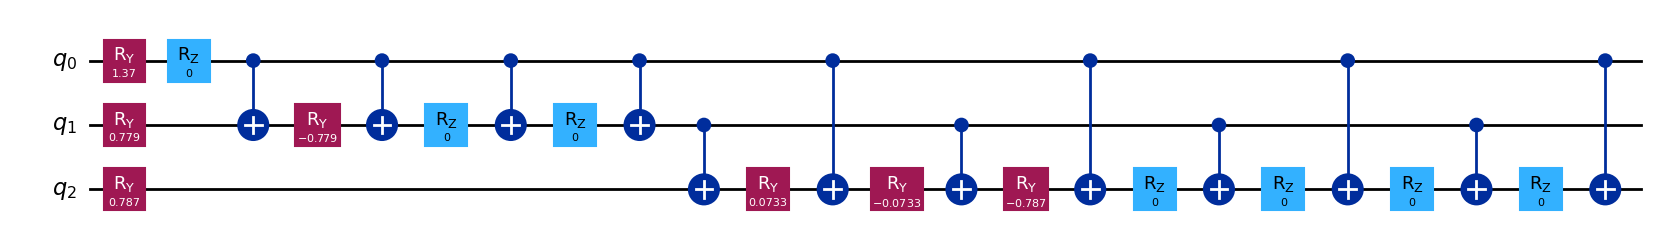

In [4]:
ckt = state_generation(v1v2_dict, n_qubit + 1)
ckt.draw(
    output="mpl",
    filename="StateGen.png",
)

## Random circuit framework

In [5]:
"""
Construct UQSD or MED circuit
"""

# Set Quantum Register
qr_alice = QuantumRegister(1, name="qr_alice")
qr_bob = QuantumRegister(n_qubit, name="qr_bob")

# Set Ancilla Register
ar = AncillaRegister(1, name="anc")

# Set Alice's Classical Register
cr_alice = ClassicalRegister(1, name="cr_alice")
# Set Bob's Classical Register
if experiment_type == "UQSD":  # for UQSD
    cr_bob = ClassicalRegister(2, name="cr_bob")

elif experiment_type == "MED":
    cr_bob = ClassicalRegister(1, name="cr_bob")  # for MED
else:
    cr_bob = ClassicalRegister(n_qubit, name="cr_bob")

# initialize circuit
circ = QuantumCircuit(qr_alice, qr_bob, cr_bob, cr_alice, ar)

# state preparation
circ.compose(U12, [j for j in range(n_qubit + 1)], inplace=True)
# restrict transformation from k to 1 qubit subspace
circ.compose(
    restrict_kto1(v1_dict, v2_dict, n_qubit), [j for j in range(1, n_qubit + 2)],
    inplace=True,
)

# Pick UQSD or MED circuit
if experiment_type == "UQSD":
    circ.compose(UQSD(v1_dict, v2_dict, n_qubit), [1, 2], inplace=True)
elif experiment_type == "MED":
    circ.compose(MED(v1_dict, v2_dict, n_qubit, p1), [1], inplace=True)
else:
    print("QSD circit has not been sepcified!")

# Record the circuit output state for check.
check_v2 = Statevector.from_instruction(circ)

# Set measurement bit
# Outcome is in the form, |a, b0, b1>, shown in paper.
circ.measure(qr_alice, cr_alice)
if experiment_type == "UQSD":  # for UQSD
    circ.measure(qr_bob[0], cr_bob[1])
    circ.measure(qr_bob[1], cr_bob[0])

elif experiment_type == "MED":  # for MED
    circ.measure(qr_bob[0], cr_bob)
else:
    circ.measure(qr_bob, cr_bob)

circ.draw()

┌────────────┐┌───────┐                                        »
  qr_alice: ─┤ Ry(1.3694) ├┤ Rz(0) ├──■────────────────────■─────────────■──»
            ┌┴────────────┤└───────┘┌─┴─┐┌──────────────┐┌─┴─┐┌───────┐┌─┴─┐»
  qr_bob_0: ┤ Ry(0.77944) ├─────────┤ X ├┤ Ry(-0.77944) ├┤ X ├┤ Rz(0) ├┤ X ├»
            ├─────────────┤         └───┘└──────────────┘└───┘└───────┘└───┘»
  qr_bob_1: ┤ Ry(0.78692) ├─────────────────────────────────────────────────»
            └────┬───┬────┘                                                 »
       anc: ─────┤ X ├──────────────────────────────────────────────────────»
                 └───┘                                                      »
  cr_bob: 2/════════════════════════════════════════════════════════════════»
                                                                            »
cr_alice: 1/════════════════════════════════════════════════════════════════»
                                                                            »
«                                                                          »
«  qr_alice: ───────────■─────────────────────────■────────────────────────»
«            ┌───────┐┌─┴─┐                       │                        »
«  qr_bob_0: ┤ Rz(0) ├┤ X ├──■────────────────────┼─────────────────────■──»
«            └───────┘└───┘┌─┴─┐┌──────────────┐┌─┴─┐┌───────────────┐┌─┴─┐»
«  qr_bob_1: ──────────────┤ X ├┤ Ry(0.073324) ├┤ X ├┤ Ry(-0.073324) ├┤ X ├»
«                          └───┘└──────────────┘└───┘└───────────────┘└───┘»
«       anc: ──────────────────────────────────────────────────────────────»
«                                                                          »
«  cr_bob: 2/══════════════════════════════════════════════════════════════»
«                                                                          »
«cr_alice: 1/══════════════════════════════════════════════════════════════»
«                                                                          »
«                                                                           »
«  qr_alice: ──────────────────■───────────────────────────■────────────────»
«                              │                           │                »
«  qr_bob_0: ──────────────────┼─────────────■─────────────┼─────────────■──»
«            ┌──────────────┐┌─┴─┐┌───────┐┌─┴─┐┌───────┐┌─┴─┐┌───────┐┌─┴─┐»
«  qr_bob_1: ┤ Ry(-0.78692) ├┤ X ├┤ Rz(0) ├┤ X ├┤ Rz(0) ├┤ X ├┤ Rz(0) ├┤ X ├»
«            └──────────────┘└───┘└───────┘└───┘└───────┘└───┘└───────┘└───┘»
«       anc: ───────────────────────────────────────────────────────────────»
«                                                                           »
«  cr_bob: 2/═══════════════════════════════════════════════════════════════»
«                                                                           »
«cr_alice: 1/═══════════════════════════════════════════════════════════════»
«                                                                           »
«                               ┌─┐                                          »
«  qr_alice: ───────────■───────┤M├──────────────────────────────────────────»
«                       │       └╥┘                                          »
«  qr_bob_0: ───────────┼────■───╫────────────■─────────────■─────────────■──»
«            ┌───────┐┌─┴─┐┌─┴─┐ ║ ┌───────┐┌─┴─┐┌───────┐┌─┴─┐┌───────┐┌─┴─┐»
«  qr_bob_1: ┤ Rz(0) ├┤ X ├┤ X ├─╫─┤ Rz(0) ├┤ X ├┤ Rz(0) ├┤ X ├┤ Ry(0) ├┤ X ├»
«            └───────┘└───┘└───┘ ║ └───────┘└───┘└───────┘└───┘└───────┘└───┘»
«       anc: ────────────────────╫───────────────────────────────────────────»
«                                ║                                           »
«  cr_bob: 2/════════════════════╬═══════════════════════════════════════════»
«                                ║                                           »
«cr_alice: 1/════════════════════╩═══════════════════════════════════════════»
«                                0  

In [6]:
"""
Check the theoretical result
"""

v1v2_inner = abs(np.vdot(v1, v2))
print("<v1|v2> = ", v1v2_inner)

test_outcome = [treat_as_zero(abs(j)) ** 2 for j in check_v2]

test_dict = {}

for i in range(len(test_outcome)):
    if experiment_type == "UQSD":
        bit_list = 3
    elif experiment_type == "MED":
        bit_list = 2
    else:
        print("Please, set experiment_type = 'UQSD' or 'MED'")
        break
    if test_outcome[i] == 0:
        pass
    else:
        test_dict[format(i, f"0{n_qubit+2}b")[-bit_list:][::-1]] = test_outcome[i]
print("The outcome is of the form: |a, b0, b1 >")
print(f"{experiment_type} theoretical result = ", test_dict)


if experiment_type == "UQSD":
    print("Success rate = ", 1 - (v1v2_inner / 2))
elif experiment_type == "MED":
    print(
        "Success rate = ", 1 / 2 + np.sqrt(1 - 4 * p1 * (1 - p1) * (v1v2_inner**2)) / 2
    )

<v1|v2> =  0.4639543445425221
The outcome is of the form: |a, b0, b1 >
UQSD theoretical result =  {'000': 0.321627393274487, '110': 0.21441826218299104, '001': 0.2783726067255133, '101': 0.18558173781700885}
Success rate =  0.768022827728739


In [12]:
import matplotlib.pyplot as plt


def build_QSD_circuit(
    experiment_type="UQSD",
    p1=0.6,
    c0_bob=0.1,
    n_qubit=2,
    seed=0,
) -> QuantumCircuit:
    statevec_alice = [1]
    statevec_alice.extend([0 for j in range(1, 2**n_qubit)])
    statevec_alice = np.array(statevec_alice)

    # abs for arbitrary real-coefficient state
    # remove abs for arbitrary complex state
    statevec_bob = [sqrt(c0_bob)]
    statevec_bob.extend(
        np.sqrt(1 - c0_bob)
        * np.abs(random_statevector(dims=2**n_qubit - 1, seed=seed)),
    )

    ## print(statevec_bob)
    statevec_bob = unit_vector_check(statevec_bob)
    # print(statevec_bob)

    """
    Convert np.array into dict, which is the input requirement of the
    following gate.
    """
    v1_dict = {}
    v2_dict = {}
    v1v2_dict = {}  # v1v2 = sqrt(p1)|v1> + sqrt(1-p1)|v2>
    for i in range(2**n_qubit):
        v1_dict[format(i, f"0{n_qubit}b")] = statevec_alice[i]
        v2_dict[format(i, f"0{n_qubit}b")] = statevec_bob[i]
        v1v2_dict[format(i, f"0{n_qubit}b") + "0"] = sqrt(p1) * statevec_alice[i]
        v1v2_dict[format(i, f"0{n_qubit}b") + "1"] = sqrt(1 - p1) * statevec_bob[i]

    # Unitary gate for state preparation
    U12 = state_generation(v1v2_dict, n_qubit + 1)

    """
    Construct UQSD or MED circuit
    """

    # Registers
    qr_alice = QuantumRegister(1, name="qr_alice")
    qr_bob = QuantumRegister(n_qubit, name="qr_bob")
    ar = AncillaRegister(1, name="anc")
    cr_alice = ClassicalRegister(1, name="cr_alice")
    if experiment_type == "UQSD":
        cr_bob = ClassicalRegister(2, name="cr_bob")
    elif experiment_type == "MED":
        cr_bob = ClassicalRegister(1, name="cr_bob")
    else:
        cr_bob = ClassicalRegister(n_qubit, name="cr_bob")

    # Initialize circuit
    circ = QuantumCircuit(qr_alice, qr_bob, cr_bob, cr_alice, ar)

    # state preparation
    circ.append(
        U12,
        [j for j in range(n_qubit + 1)],
    )
    # restrict transformation from k to 1 qubit subspace
    circ.append(
        restrict_kto1(v1_dict, v2_dict, n_qubit),
        [j for j in range(1, n_qubit + 2)],
    )

    # Pick UQSD or MED circuit
    if experiment_type == "UQSD":
        circ.append(UQSD(v1_dict, v2_dict, n_qubit), [1, 2])
    elif experiment_type == "MED":
        circ.append(MED(v1_dict, v2_dict, n_qubit, p1), [1])
    else:
        print("QSD circit has not been specified!")

    # Record the circuit output state for check.
    check_v2 = Statevector.from_instruction(circ)

    # Set measurement bit
    # Outcome is in the form, |a, b0, b1>, shown in paper.
    circ.measure(qr_alice, cr_alice)
    if experiment_type == "UQSD":
        circ.measure(qr_bob[0], cr_bob[1])
        circ.measure(qr_bob[1], cr_bob[0])

    elif experiment_type == "MED":
        circ.measure(qr_bob[0], cr_bob)
    else:
        circ.measure(qr_bob, cr_bob)

    # circ.draw(
    #     output="mpl",
    #     filename=f"./exp0/figures/" + "exp0" + f"_{experiment_type}"
    #     # + f"_{c0_bob:.3f}"
    #     # + f"_{n_qubit}_{seed}"
    #     + ".png",
    # )
    # plt.close()
    return circ


def exp0(
    experiment_type="UQSD",
    num_points=40,
    num_rounds=4,
    shots=4096
    n_qubit=2,
    p1=0.5,
    print_circ=True,
    sim=False,
    ibmq=True,
    backend="ibm_osaka",
):
    # Generate circuits
    circuits: list[QuantumCircuit] = []
    for i in range(1, num_points):
        for j in range(num_rounds):
            c0_bob = i / num_points
            circuits.append(
                build_QSD_circuit(
                    experiment_type=experiment_type,
                    p1=p1,
                    c0_bob=c0_bob,
                    n_qubit=n_qubit,
                    # seed=i * j,
                    seed=i * num_rounds + j,
                )
            )

    # Run the circuits
    import matplotlib.colors as mcolors

    colors = list(mcolors.TABLEAU_COLORS)

    import sys, os

    func_name = sys._getframe().f_code.co_name
    if print_circ:
        if not os.path.exists(f".//{func_name}"):
            os.mkdir(f".//{func_name}")
        if not os.path.exists(f".//{func_name}//figures"):
            os.mkdir(f".//{func_name}//figures")

    if sim:
        if not os.path.exists(f".//{func_name}"):
            os.mkdir(f".//{func_name}")
        if not os.path.exists(f".//{func_name}//results"):
            os.mkdir(f".//{func_name}//results")

    if ibmq:
        if not os.path.exists(f".//{func_name}"):
            os.mkdir(f".//{func_name}")
        if not os.path.exists(f".//{func_name}//results"):
            os.mkdir(f".//{func_name}//results")

    # if sim:
    #     plt.figure(
    #         dpi=600
    #     )  # https://stackoverflow.com/questions/39870642/how-to-plot-a-high-resolution-graph
    #     # Theoretical lines
    #     x_axis = np.linspace(0, 2, num_points)
    #     for t in range(max_shift):
    #         theo = 0.5 * (1 + max(1 - (1 / 2**n) * t, 0) * np.cos(angles))
    #         plt.plot(x_axis, theo, "-", color=colors[t], alpha=0.5)
    #
    #     aer_sim = AerSimulator(method="statevector")
    #     job = aer_sim.run(circuits=circuits)
    #     counts_list = job.result().get_counts()
    #     for t in range(max_shift):
    #         prob = []
    #         for i in range(num_points):
    #             total_counts = 0
    #             zero_counts = 0
    #             for key in counts_list[t * num_points + i].keys():
    #                 total_counts += counts_list[t * num_points + i][key]
    #                 if key[0] == "0":
    #                     zero_counts += counts_list[t * num_points + i][key]
    #             prob.append(zero_counts / total_counts)
    #         plt.plot(x_axis, prob, ".", label=f"t = {t}", color=colors[t])
    #
    #     plt.xlabel(r"$\theta / \pi$" + f" ({num_points} points) (n = {n}, k = {k})")
    #     plt.ylabel("Probability for path 0")
    #     plt.legend(loc="lower right")
    #     plt.title("First-order Interference (Aer Simulator)")
    #     plt.grid(True)
    #     plt.savefig(
    #         fname=f"{os.getcwd()}/{func_name}/results/"
    #         + func_name
    #         + "_result_sim"
    #         + f"_{n}_{k}"
    #         + ".png",
    #         bbox_inches="tight",
    #     )
    #     plt.close()
    #     # TODO
    #     # Output counts to files

    if ibmq:
        from qiskit_ibm_runtime import QiskitRuntimeService, Batch, Sampler

        service = QiskitRuntimeService(channel="ibm_quantum")
        backend = service.backend(backend)
        # To run on hardware, select the backend with the fewest number of jobs in the queue
        # backend = service.least_busy(operational=True, simulator=False)
        print(
            f"Name: {backend.name}\n"
            f"Version: {backend.version}\n"
            f"No. of qubits: {backend.num_qubits}\n"
        )

        from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

        target = backend.target

        from qiskit import qasm2

        circuits_ibm = []
        for circuit in circuits:
            # pm = generate_preset_pass_manager(target=target, optimization_level=3)
            # pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
            # circuit_ibm = pm.run(circuit)
            circuit_ibm = transpile(circuit, backend=backend, optimization_level=3)
            print(f"{circuit_ibm.count_ops()}")
            print(f"Layers: {circuit_ibm.depth()}")
            # For Qiskit 0.46
            # circuit_clean = QuantumCircuit.from_qasm_str(circuit_ibm.qasm())
            circuit_clean = QuantumCircuit.from_qasm_str(qasm2.dumps(circuit_ibm))
            circuits_ibm.append(circuit_clean)
            if print_circ:
                # circuit_ibm.draw(
                #     output="mpl",
                #     filename=f"./exp0/figures/"
                #     + "exp0"
                #     + f"_{experiment_type}_transpile"
                #     # + f"_{c0_bob:.3f}"
                #     # + f"_{n_qubit}_{seed}"
                #     + ".png",
                # )
                pass

        job = backend.run(circuits=circuits_ibm, shots=shots)
        print(job.job_id())

        # TODO
        # Plot later
    return circuits_ibm

KeyboardInterrupt: 

In [ ]:
# circuits_ibm = exp0(backend="ibmq_qasm_simulator")
exp0(
    experiment_type="MED",
    backend="ibmq_kolkata",
)
exp0(
    experiment_type="MED",
    backend="ibm_osaka",
)
# exp0(backend="ibm_kyoto")

In [ ]:
"""
This part should be replaced by the Real Device Experiment with
Qiskit 1.0 !!!
"""

from qiskit.primitives import Sampler

# specify backend...
simulator = BasicProvider().get_backend("basic_simulator")

# transpile
circ_t = transpile(circuits_ibm[0], simulator, optimization_level=3)  # optimization_level=3
print("gates = ", circ_t.count_ops())
print("depth = ", circ_t.depth())
print("2-qubit gate = ", circ_t.num_nonlocal_gates())

# run the job
sampler_sim = Sampler()
job_sim = sampler_sim.run(circ_t, shots=4000)
result = job_sim.result()
print("simulation result = ", result.quasi_dists[0].binary_probabilities())

gates =  OrderedDict([('cx', 21), ('u3', 14), ('u', 12), ('u1', 11), ('measure', 3), ('h', 1), ('unitary', 1), ('u2', 1)])
depth =  43
2-qubit gate =  22
simulation result =  {'000': 0.43, '001': 0.07875, '101': 0.0785, '110': 0.41275}


## Compromise experiment framework (If the above experiment performed worse.)

In [ ]:
# State preparation gate
U1 = state_generation(v1_dict, n_qubit)
U2 = state_generation(v2_dict, n_qubit)
# cU1= U1.control(1) # for compromise experiment
# cU2= U2.control(1) # for compromise experiment

# Costruct circuit
circ_list = []
for Ui in [U1, U2]:
    qr = QuantumRegister(n_qubit)
    ar = AncillaRegister(1)
    # Set Bob's ClassicalRegister
    if experiment_type == "UQSD":  # for UQSD
        cr = ClassicalRegister(2)
    elif experiment_type == "MED":
        cr = ClassicalRegister(1)  # for MED
    else:
        cr = ClassicalRegister(n_qubit)

    circ_c = QuantumCircuit(qr, cr, ar)
    circ_c.append(Ui, qr)
    circ_c.append(
        restrict_kto1(v1_dict, v2_dict, n_qubit), [j for j in range(n_qubit + 1)]
    )

    if experiment_type == "UQSD":
        circ_c.append(UQSD(v1_dict, v2_dict, n_qubit), [0, 1])
        circ_c.measure([1, 0], cr)
    elif experiment_type == "MED":
        circ_c.append(MED(v1_dict, v2_dict, n_qubit, p1), [0])
        circ_c.measure([0], cr)
    else:
        circ_c.measure(qr, cr)
        print("QSD circit has not been sepcified!")
    circ_list.append(circ_c)